<a href="https://colab.research.google.com/github/OnkarBasu/DLimagesegmentation/blob/main/imageseg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Install + Mount Drive + GPU check
# ═══════════════════════════════════════════════════════════════
!pip install fiftyone albumentations --quiet

from google.colab import drive
drive.mount('/content/drive')

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU!")
print("Drive mounted!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 74.7 MB/s eta 0:00

In [33]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — 3 classes: Background, Person, Vehicle
# ═══════════════════════════════════════════════════════════════
import os, random
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 3 classes — clean and visually distinct ───────────────────
CLASSES      = ["Person", "Car", "Truck"]   # still download both
CLASS_TO_IDX = {"Person": 1, "Car": 2, "Truck": 2}  # Truck → Vehicle(2)
NUM_CLASSES  = 3    # background=0, person=1, vehicle=2
CLASS_NAMES  = ["Background", "Person", "Vehicle"]

# ── Settings for Colab T4 ─────────────────────────────────────
IMG_SIZE     = 160
BATCH_SIZE   = 16
EPOCHS       = 40
LR           = 1e-3
TRAIN_N      = 1000
TEST_N       = 100
SEED         = 42
PATIENCE     = 12

# ── Paths ─────────────────────────────────────────────────────
DRIVE_BASE     = Path("/content/drive/MyDrive/segmentation_project")
TRAIN_IMG_DIR  = DRIVE_BASE / "data" / "train" / "images"
TRAIN_MASK_DIR = DRIVE_BASE / "data" / "train" / "masks"
TEST_IMG_DIR   = DRIVE_BASE / "data" / "test"  / "images"
TEST_MASK_DIR  = DRIVE_BASE / "data" / "test"  / "masks"
CHECKPOINT     = str(DRIVE_BASE / "best_model_vehicle.pth")  # new name
RESULTS_DIR    = DRIVE_BASE / "results"

for d in [TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Colours ───────────────────────────────────────────────────
COLORS = {
    0: (100, 100, 100),   # background — gray
    1: (127, 119, 221),   # person     — purple
    2: (216,  90,  48),   # vehicle    — orange (Car + Truck merged)
}

def mask_to_rgb(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for idx, color in COLORS.items():
        rgb[mask == idx] = color
    return rgb

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device     : {device}")
print(f"GPU        : {torch.cuda.get_device_name(0)}")
print(f"Classes    : {CLASS_NAMES}")
print(f"NUM_CLASSES: {NUM_CLASSES}  (was 4, now 3)")
print(f"Key change : Car=2 and Truck=2 → both = Vehicle")
print(f"IMG_SIZE   : {IMG_SIZE}")
print(f"EPOCHS     : {EPOCHS}")
print(f"Expected   : ~35s/epoch × 60 = ~35 min with early stopping")

Device     : cuda
GPU        : Tesla T4
Classes    : ['Background', 'Person', 'Vehicle']
NUM_CLASSES: 3  (was 4, now 3)
Key change : Car=2 and Truck=2 → both = Vehicle
IMG_SIZE   : 160
EPOCHS     : 40
Expected   : ~35s/epoch × 60 = ~35 min with early stopping


In [34]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Download data
# ═══════════════════════════════════════════════════════════════

import fiftyone as fo
import fiftyone.zoo as foz

def download_split(split, n, img_dir, mask_dir, name):
    existing = list(img_dir.glob("*.jpg"))
    if len(existing) >= int(n * 0.85):
        print(f"[SKIP] {split} already has {len(existing)} images on Drive")
        return len(existing)

    print(f"\nDownloading {n} {split} images...")
    if name in fo.list_datasets():
        fo.delete_dataset(name)

    ds = foz.load_zoo_dataset(
        "open-images-v7", split=split,
        label_types=["segmentations"], classes=CLASSES,
        max_samples=n, shuffle=True, seed=SEED, dataset_name=name,
    )

    saved, skipped, errors = 0, 0, {}
    for sample in tqdm(ds, desc=f"Saving {split} to Drive"):
        if not os.path.exists(sample.filepath):
            skipped += 1; continue
        seg_field = sample.ground_truth
        if seg_field is None:
            skipped += 1; continue
        dets = seg_field.detections
        if not dets:
            skipped += 1; continue
        try:
            img  = Image.open(sample.filepath).convert("RGB")
            W, H = img.size
            label_map = np.zeros((H, W), dtype=np.uint8)
            for det in dets:
                if det.label not in CLASS_TO_IDX or det.mask is None:
                    continue
                idx = CLASS_TO_IDX[det.label]
                bx, by, bw, bh = det.bounding_box
                x1, y1 = int(bx*W), int(by*H)
                x2, y2 = min(int((bx+bw)*W),W), min(int((by+bh)*H),H)
                bw_px, bh_px = max(1,x2-x1), max(1,y2-y1)
                crop = det.mask.astype(np.uint8)*255
                if crop.shape[:2] != (bh_px, bw_px):
                    crop = np.array(Image.fromarray(crop).resize(
                        (bw_px,bh_px), Image.NEAREST))
                label_map[y1:y2, x1:x2][crop>127] = idx
            stem = Path(sample.filepath).stem
            img.save(img_dir / f"{stem}.jpg")
            Image.fromarray(label_map).save(mask_dir / f"{stem}.png")
            saved += 1
        except Exception as e:
            errors[type(e).__name__] = errors.get(type(e).__name__,0)+1
            skipped += 1

    print(f"  Saved: {saved}  Skipped: {skipped}")
    if errors: print(f"  Errors: {errors}")
    return saved

download_split("train", TRAIN_N, TRAIN_IMG_DIR, TRAIN_MASK_DIR, "oi-train-4cls-v2")
download_split("test",  TEST_N,  TEST_IMG_DIR,  TEST_MASK_DIR,  "oi-test-4cls-v2")

print(f"\nTrain images: {len(list(TRAIN_IMG_DIR.glob('*.jpg')))}")
print(f"Test images:  {len(list(TEST_IMG_DIR.glob('*.jpg')))}")

[SKIP] train already has 1441 images on Drive
[SKIP] test already has 100 images on Drive

Train images: 1441
Test images:  100


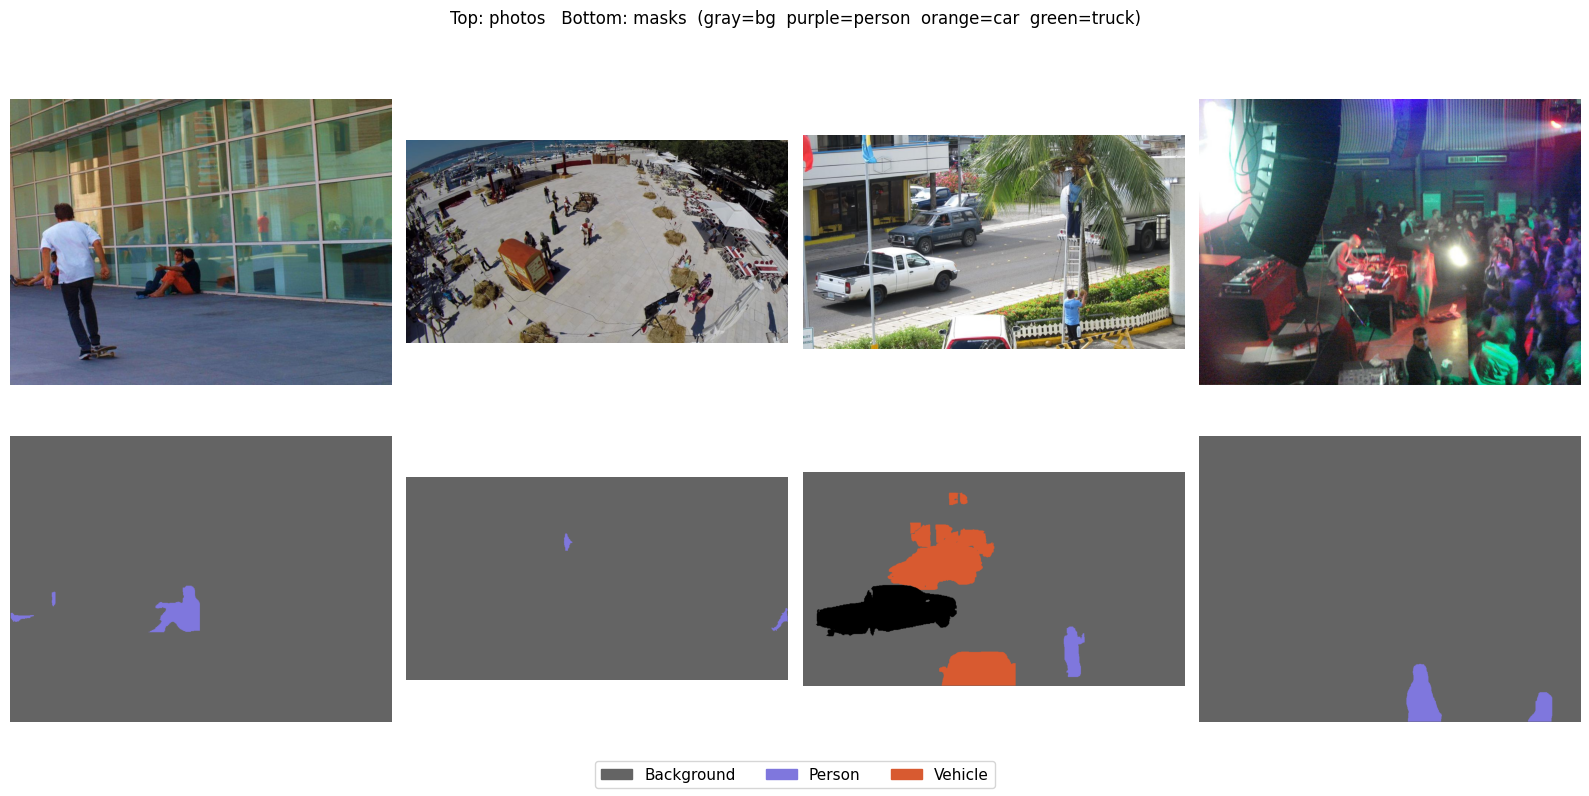

Saved to Drive: /content/drive/MyDrive/segmentation_project/results/data_check.png

Class pixel distribution in first 50 training masks:
  Background  : 93.7%
  Person      : 2.1%
  Vehicle     : 4.2%


In [35]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Visual check + save to Drive
# ═══════════════════════════════════════════════════════════════
stems = [p.stem for p in TRAIN_MASK_DIR.glob("*.png")]
assert len(stems) > 0, "No training data found!"

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Top: photos   Bottom: masks  (gray=bg  purple=person  orange=car  green=truck)",
             fontsize=12)

for col, stem in enumerate(random.sample(stems, 4)):
    img  = Image.open(TRAIN_IMG_DIR  / f"{stem}.jpg")
    mask = np.array(Image.open(TRAIN_MASK_DIR / f"{stem}.png"))
    axes[0, col].imshow(img);               axes[0, col].axis("off")
    axes[1, col].imshow(mask_to_rgb(mask)); axes[1, col].axis("off")

patches = [mpatches.Patch(color=[c/255 for c in COLORS[i]], label=CLASS_NAMES[i])
           for i in range(NUM_CLASSES)]
fig.legend(handles=patches, loc="lower center", ncol=NUM_CLASSES, fontsize=11)
plt.tight_layout()

# Save to Drive
save_path = str(RESULTS_DIR / "data_check.png")
plt.savefig(save_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved to Drive: {save_path}")

# Class distribution check
print("\nClass pixel distribution in first 50 training masks:")
counts_check = np.zeros(NUM_CLASSES, dtype=np.int64)
for stem in stems[:50]:
    m = np.array(Image.open(TRAIN_MASK_DIR / f"{stem}.png"))
    for c in range(NUM_CLASSES):
        counts_check[c] += int((m == c).sum())
for i, name in enumerate(CLASS_NAMES):
    pct = counts_check[i] / counts_check.sum() * 100
    print(f"  {name:<12}: {pct:.1f}%")

In [36]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — AttentionUNet for 3 classes
# Only change: out_channels = NUM_CLASSES = 3
# ═══════════════════════════════════════════════════════════════
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)


class AttentionGate(nn.Module):
    def __init__(self, f_g, f_l, f_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(f_g, f_int, 1, bias=False),
            nn.BatchNorm2d(f_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(f_l, f_int, 1, bias=False),
            nn.BatchNorm2d(f_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(f_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1  = self.W_g(g)
        x1  = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=NUM_CLASSES,
                 features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups   = nn.ModuleList()
        self.att   = nn.ModuleList()
        self.pool  = nn.MaxPool2d(2, 2)

        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, 2, 2)
            )
            self.att.append(
                AttentionGate(f_g=feature, f_l=feature,
                              f_int=feature//2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2,
                                     dropout_p=0.2)
        # out_channels=3 now (Background, Person, Vehicle)
        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for idx in range(0, len(self.ups), 2):
            x    = self.ups[idx](x)
            skip = skips[idx // 2]
            if x.shape != skip.shape:
                x = TF.resize(x, size=skip.shape[2:])
            skip = self.att[idx//2](g=x, x=skip)
            x    = self.ups[idx+1](torch.cat([skip, x], dim=1))

        return self.final_conv(x)


# Verify
model = AttentionUNet().to(device)
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
out   = model(dummy)
assert out.shape == (1, NUM_CLASSES, IMG_SIZE, IMG_SIZE), \
    f"Expected (1,{NUM_CLASSES},{IMG_SIZE},{IMG_SIZE}) got {out.shape}"

total_params = sum(p.numel() for p in model.parameters())
gpu_mb = torch.cuda.memory_allocated() / 1024**2
print(f"Output shape : {out.shape}  ✓")
print(f"Output means : {NUM_CLASSES} scores per pixel")
print(f"  score[0] = Background probability")
print(f"  score[1] = Person probability")
print(f"  score[2] = Vehicle probability (Car + Truck merged)")
print(f"Parameters   : {total_params:,}")
print(f"GPU memory   : {gpu_mb:.0f} MB")
del dummy, out
torch.cuda.empty_cache()

Output shape : torch.Size([1, 3, 160, 160])  ✓
Output means : 3 scores per pixel
  score[0] = Background probability
  score[1] = Person probability
  score[2] = Vehicle probability (Car + Truck merged)
Parameters   : 31,388,331
GPU memory   : 790 MB


In [37]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Dataset with mask remapping + correct weights
# ═══════════════════════════════════════════════════════════════
class SegDataset(Dataset):
    """
    Loads image + mask pairs.
    KEY CHANGE: remaps Truck(3) → Vehicle(2) during loading
    So masks only ever contain values 0, 1, 2
    """
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir  = Path(mask_dir)
        self.transform = transform
        self.images = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith(".jpg") and
            os.path.exists(os.path.join(mask_dir,
                           f.replace(".jpg", ".png")))
        ])
        print(f"  {Path(image_dir).parent.name}: {len(self.images)} pairs")

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        stem  = Path(self.images[idx]).stem
        image = np.array(Image.open(
            self.image_dir/f"{stem}.jpg").convert("RGB"))
        mask  = np.array(Image.open(
            self.mask_dir/f"{stem}.png"), dtype=np.int64)

        # ── KEY: remap Truck(3) → Vehicle(2) ─────────────────
        # Masks on disk still have Car=2 and Truck=3
        # We merge both into Vehicle=2
        mask[mask == 3] = 2   # Truck becomes Vehicle
        mask = np.clip(mask, 0, NUM_CLASSES - 1)  # safety: 0,1,2 only

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"]
        return image, mask


# ── Augmentation ──────────────────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.RandomRotate90(p=0.2),
    A.ColorJitter(brightness=0.3, contrast=0.3,
                  saturation=0.2, hue=0.1, p=0.4),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]),
    ToTensorV2(),
])

print("Creating datasets...")
train_ds = SegDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_transform)
test_ds  = SegDataset(TEST_IMG_DIR,  TEST_MASK_DIR,  test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

# Verify remapping worked
imgs, masks = next(iter(train_loader))
unique_vals = masks.unique().tolist()
print(f"\nMask unique values after remapping: {unique_vals}")
assert 3 not in unique_vals, "Truck(3) still present — remap failed!"
assert max(unique_vals) <= 2,  "Values above 2 found — check remap!"
print("Remap verified ✓ — masks only contain 0, 1, 2")


# ── Count pixels after remapping ──────────────────────────────
print("\nCounting pixels after Truck→Vehicle remapping...")
counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for mask_path in TRAIN_MASK_DIR.glob("*.png"):
    m = np.array(Image.open(mask_path), dtype=np.int64)
    m[m == 3] = 2          # apply same remap
    m = np.clip(m, 0, NUM_CLASSES - 1)
    for c in range(NUM_CLASSES):
        counts[c] += int((m == c).sum())

print("\nPixel distribution after merge:")
for i, name in enumerate(CLASS_NAMES):
    pct = counts[i] / counts.sum() * 100
    print(f"  {name:<12}: {counts[i]:>15,}  ({pct:.3f}%)")

# ── Median frequency weights ───────────────────────────────────
freqs    = counts / counts.sum()
median_f = np.median(freqs)
weights  = median_f / freqs
weights  = np.clip(weights, 0.05, 10.0)
weights  = weights / weights.sum() * NUM_CLASSES

print(f"\nMedian frequency: {median_f*100:.3f}%")
print(f"\nClass weights:")
print(f"  {'Class':<12} {'Freq%':>8}  {'Weight':>8}")
print(f"  {'-'*32}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<12} {freqs[i]*100:>7.3f}%  {weights[i]:>8.4f}")

# Expected approximately:
# Background : freq=84%  weight=~0.14  (very common, low weight)
# Person     : freq= 4%  weight=~2.90  (rare, high weight)
# Vehicle    : freq=12%  weight=~1.00  (Car+Truck merged, reference)

assert all(weights > 0),  "Zero weight detected!"
assert all(weights < 15), "Weight too extreme!"
weight_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"\nWeight tensor: {weight_tensor}")


# ── Dice Loss ─────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs           = torch.softmax(logits, dim=1)
        targets_one_hot = torch.zeros_like(probs)
        targets_one_hot.scatter_(1, targets.unsqueeze(1), 1)
        intersection = (probs * targets_one_hot).sum(dim=(2, 3))
        union        = (probs.sum(dim=(2, 3)) +
                        targets_one_hot.sum(dim=(2, 3)))
        dice         = (2*intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


# ── Combined Loss ─────────────────────────────────────────────
class CombinedLoss(nn.Module):
    def __init__(self, weights, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce     = nn.CrossEntropyLoss(weight=weights)
        self.dice   = DiceLoss()
        self.ce_w   = ce_weight
        self.dice_w = dice_weight

    def forward(self, logits, targets):
        return (self.ce_w   * self.ce(logits, targets) +
                self.dice_w * self.dice(logits, targets))


# ── Build everything ──────────────────────────────────────────
model     = AttentionUNet().to(device)
criterion = CombinedLoss(weight_tensor)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=1e-4
)

def lr_lambda(epoch):
    warmup = 5
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(EPOCHS - warmup, 1)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"\nModel      : AttentionUNet [64,128,256,512]")
print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Classes    : {CLASS_NAMES}")
print(f"Loss       : CrossEntropy + Dice")
print(f"Optimiser  : AdamW  lr={LR}  wd=1e-4")
print(f"Epochs     : {EPOCHS}  Patience: {PATIENCE}")
print(f"\nRun: Cell 7A → 7B → 7C → 8 → 9 → 10")


Creating datasets...
  train: 1441 pairs
  test: 100 pairs

Mask unique values after remapping: [0, 1, 2]
Remap verified ✓ — masks only contain 0, 1, 2

Counting pixels after Truck→Vehicle remapping...

Pixel distribution after merge:
  Background  :     896,349,271  (84.189%)
  Person      :      40,754,878  (3.828%)
  Vehicle     :     127,581,675  (11.983%)

Median frequency: 11.983%

Class weights:
  Class           Freq%    Weight
  --------------------------------
  Background    84.189%    0.0999
  Person         3.828%    2.1979
  Vehicle       11.983%    0.7021

Weight tensor: tensor([0.0999, 2.1979, 0.7021], device='cuda:0')

Model      : AttentionUNet [64,128,256,512]
Parameters : 31,388,331
Classes    : ['Background', 'Person', 'Vehicle']
Loss       : CrossEntropy + Dice
Optimiser  : AdamW  lr=0.001  wd=1e-4
Epochs     : 40  Patience: 12

Run: Cell 7A → 7B → 7C → 8 → 9 → 10


Training loop

In [38]:
# ═══════════════════════════════════════════════════════════════
# CELL 7A — Copy data from Drive to local SSD
# ═══════════════════════════════════════════════════════════════
import shutil, time, sys

LOCAL_TRAIN_IMG  = Path("/content/local_data/train/images")
LOCAL_TRAIN_MASK = Path("/content/local_data/train/masks")
LOCAL_TEST_IMG   = Path("/content/local_data/test/images")
LOCAL_TEST_MASK  = Path("/content/local_data/test/masks")

for d in [LOCAL_TRAIN_IMG, LOCAL_TRAIN_MASK,
          LOCAL_TEST_IMG,  LOCAL_TEST_MASK]:
    d.mkdir(parents=True, exist_ok=True)

def copy_dir(src, dst, label):
    src_files = list(Path(src).glob("*.*"))
    dst_files = list(dst.glob("*.*"))

    if len(src_files) == 0:
        print(f"[WARNING] {label} source is empty: {src}")
        return

    if len(dst_files) >= int(len(src_files) * 0.95):
        print(f"[SKIP] {label} already on local SSD "
              f"({len(dst_files)}/{len(src_files)} files)")
        return

    print(f"Copying {len(src_files)} {label} "
          f"from Drive → local SSD...")
    start = time.time()
    for f in tqdm(src_files, ncols=70):
        shutil.copy2(f, dst / f.name)
    elapsed = time.time() - start
    print(f"  Done in {elapsed:.0f}s  "
          f"speed: {len(src_files)/elapsed:.0f} files/sec",
          flush=True)

copy_dir(TRAIN_IMG_DIR,  LOCAL_TRAIN_IMG,  "train images")
copy_dir(TRAIN_MASK_DIR, LOCAL_TRAIN_MASK, "train masks")
copy_dir(TEST_IMG_DIR,   LOCAL_TEST_IMG,   "test images")
copy_dir(TEST_MASK_DIR,  LOCAL_TEST_MASK,  "test masks")

# Final count verification
print(f"\nLocal SSD contents:")
print(f"  Train images : {len(list(LOCAL_TRAIN_IMG.glob('*.jpg')))}")
print(f"  Train masks  : {len(list(LOCAL_TRAIN_MASK.glob('*.png')))}")
print(f"  Test images  : {len(list(LOCAL_TEST_IMG.glob('*.jpg')))}")
print(f"  Test masks   : {len(list(LOCAL_TEST_MASK.glob('*.png')))}")
print(f"\nData ready on local SSD!", flush=True)

[SKIP] train images already on local SSD (1441/1441 files)
[SKIP] train masks already on local SSD (1441/1441 files)
[SKIP] test images already on local SSD (100/100 files)
[SKIP] test masks already on local SSD (100/100 files)

Local SSD contents:
  Train images : 1441
  Train masks  : 1441
  Test images  : 100
  Test masks   : 100

Data ready on local SSD!


In [39]:
# CELL 7B — recreate datasets with new IMG_SIZE=160
train_ds_local = SegDataset(
    LOCAL_TRAIN_IMG, LOCAL_TRAIN_MASK,
    transform=train_transform   # ← now uses 160x160 resize
)
test_ds_local = SegDataset(
    LOCAL_TEST_IMG, LOCAL_TEST_MASK,
    transform=test_transform    # ← now uses 160x160 resize
)

train_loader_local = DataLoader(
    train_ds_local,
    batch_size=BATCH_SIZE,      # ← now 16 instead of 8
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,
)
test_loader_local = DataLoader(
    test_ds_local,
    batch_size=BATCH_SIZE,      # ← now 16 instead of 8
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,
)

imgs, masks = next(iter(train_loader_local))
print(f"Image batch : {imgs.shape}")    # should show [16, 3, 160, 160]
print(f"Mask batch  : {masks.shape}")   # should show [16, 160, 160]
print(f"Mask values : {masks.unique().tolist()}")
print(f"Train batches : {len(train_loader_local)}")  # should be ~91
print(f"Test  batches : {len(test_loader_local)}")

torch.cuda.empty_cache()
print(f"\nGPU memory : {torch.cuda.memory_allocated()/1024**2:.0f} MB")
print("Ready!", flush=True)

  train: 1441 pairs
  test: 100 pairs
Image batch : torch.Size([16, 3, 160, 160])
Mask batch  : torch.Size([16, 160, 160])
Mask values : [0, 1, 2]
Train batches : 91
Test  batches : 7

GPU memory : 364 MB
Ready!


In [40]:
# ═══════════════════════════════════════════════════════════════
# CELL 7C — Fixed training loop (with GPU monitoring)
# ═══════════════════════════════════════════════════════════════
import sys, time

# Clear GPU cache before starting
torch.cuda.empty_cache()

best_val_loss = float("inf")
train_losses  = []
val_losses    = []
no_improve    = 0

print(f"Training on  : {device}",         flush=True)
print(f"Data from    : local SSD",         flush=True)
print(f"Saves to     : {CHECKPOINT}",      flush=True)
print(f"IMG_SIZE     : {IMG_SIZE}",        flush=True)
print(f"BATCH_SIZE   : {BATCH_SIZE}\n",    flush=True)

# Print GPU memory at start
print(f"GPU memory at start  : "
      f"{torch.cuda.memory_allocated()/1024**2:.0f} MB allocated  "
      f"{torch.cuda.memory_reserved()/1024**2:.0f} MB reserved",
      flush=True)

total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ── Train ─────────────────────────────────────────────────
    model.train()
    t_loss = 0.0

    for imgs, masks in train_loader_local:
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()
        optimizer.zero_grad(set_to_none=True)
        loss  = criterion(model(imgs), masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        t_loss += loss.item()

    # ── Validate ──────────────────────────────────────────────
    model.eval()
    v_loss = 0.0

    with torch.no_grad():
        for imgs, masks in test_loader_local:
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True).long()
            v_loss += criterion(model(imgs), masks).item()

    t_loss /= len(train_loader_local)
    v_loss /= len(test_loader_local)
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step()

    # Free unused GPU memory every epoch
    torch.cuda.empty_cache()

    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]['lr']
    gpu_mb     = torch.cuda.memory_allocated() / 1024**2

    tag = ""
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), CHECKPOINT)
        no_improve = 0
        tag = "  <- saved!"
    else:
        no_improve += 1

    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"train: {t_loss:.4f}  "
        f"val: {v_loss:.4f}  "
        f"lr: {current_lr:.6f}  "
        f"time: {epoch_time:.0f}s  "
        f"GPU: {gpu_mb:.0f}MB"
        f"{tag}",
        flush=True
    )
    sys.stdout.flush()

    if no_improve >= PATIENCE:
        print(
            f"\nEarly stopping — "
            f"no improvement for {PATIENCE} epochs",
            flush=True
        )
        break

total_time = time.time() - total_start
print(f"\nTraining complete!")
print(f"Best val loss : {best_val_loss:.4f}")
print(f"Total time    : {total_time/60:.1f} minutes")
print(f"Model saved   : {CHECKPOINT}", flush=True)

Training on  : cuda
Data from    : local SSD
Saves to     : /content/drive/MyDrive/segmentation_project/best_model_vehicle.pth
IMG_SIZE     : 160
BATCH_SIZE   : 16

GPU memory at start  : 364 MB allocated  904 MB reserved
Epoch 01/40  train: 0.9058  val: 0.8457  lr: 0.000400  time: 38s  GPU: 488MB  <- saved!
Epoch 02/40  train: 0.8738  val: 0.8446  lr: 0.000600  time: 38s  GPU: 488MB  <- saved!
Epoch 03/40  train: 0.8615  val: 0.8651  lr: 0.000800  time: 38s  GPU: 488MB
Epoch 04/40  train: 0.8583  val: 0.8605  lr: 0.001000  time: 37s  GPU: 488MB
Epoch 05/40  train: 0.8516  val: 0.9360  lr: 0.001000  time: 37s  GPU: 488MB
Epoch 06/40  train: 0.8389  val: 0.8032  lr: 0.000998  time: 38s  GPU: 488MB  <- saved!
Epoch 07/40  train: 0.8356  val: 0.8484  lr: 0.000992  time: 37s  GPU: 488MB
Epoch 08/40  train: 0.8346  val: 0.7816  lr: 0.000982  time: 38s  GPU: 488MB  <- saved!
Epoch 09/40  train: 0.8186  val: 0.7715  lr: 0.000968  time: 37s  GPU: 488MB  <- saved!
Epoch 10/40  train: 0.8217  va

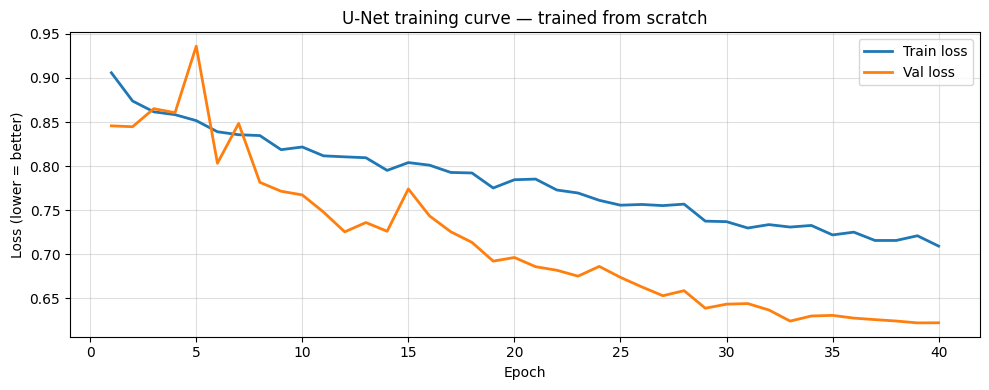

Saved to Drive: /content/drive/MyDrive/segmentation_project/results/training_curve.png


In [41]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — Training curve (saved to Drive)
# ═══════════════════════════════════════════════════════════════
actual_epochs = len(train_losses)

plt.figure(figsize=(10, 4))
plt.plot(range(1, actual_epochs+1), train_losses, label="Train loss", linewidth=2)
plt.plot(range(1, actual_epochs+1), val_losses,   label="Val loss",   linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss (lower = better)")
plt.title("U-Net training curve — trained from scratch")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()

save_path = str(RESULTS_DIR / "training_curve.png")
plt.savefig(save_path, dpi=120)
plt.show()
print(f"Saved to Drive: {save_path}")

In [42]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Fixed evaluation on 100 test images
# ═══════════════════════════════════════════════════════════════
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
model = model.to(device)
print(f"Loaded model from: {CHECKPOINT}")

# ── FIXED: use local SSD test data + correct normalisation ────
eval_loader = DataLoader(
    test_ds_local,          # ← was test_ds (Drive), now local SSD
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
print(f"Evaluating on {len(test_ds_local)} test images...\n")

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, masks in tqdm(eval_loader, desc="Evaluating"):
        imgs  = imgs.to(device)          # ← added explicit .to(device)
        preds = model(imgs).argmax(dim=1)
        all_preds.append(preds.cpu().numpy().flatten())
        all_labels.append(masks.numpy().flatten())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Check predictions are not all background
unique, counts_pred = np.unique(all_preds, return_counts=True)
print("Prediction distribution (sanity check):")
for u, c in zip(unique, counts_pred):
    print(f"  Class {u} ({CLASS_NAMES[u]}): {c:,} pixels ({c/len(all_preds)*100:.2f}%)")

# Metrics
report    = classification_report(
    all_labels, all_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    digits=4, zero_division=0,
)
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds,
                            labels=list(range(NUM_CLASSES)),
                            average=None, zero_division=0)
recall    = recall_score(all_labels, all_preds,
                         labels=list(range(NUM_CLASSES)),
                         average=None, zero_division=0)
f1        = f1_score(all_labels, all_preds,
                     labels=list(range(NUM_CLASSES)),
                     average=None, zero_division=0)

print("=" * 62)
print("  RESULTS ON 100 UNSEEN TEST IMAGES")
print("=" * 62)
print(report)
print(f"  Overall pixel accuracy : {accuracy*100:.2f}%\n")
print(f"  {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print(f"  {'-'*46}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<12} {precision[i]:>10.4f} "
          f"{recall[i]:>10.4f} {f1[i]:>10.4f}")
print(f"  {'-'*46}")
print(f"  {'Macro avg':<12} {precision.mean():>10.4f} "
      f"{recall.mean():>10.4f} {f1.mean():>10.4f}")
print("=" * 62)

# Save to Drive
results_txt = str(RESULTS_DIR / "evaluation_results.txt")
with open(results_txt, "w") as f:
    f.write("Results on 100 unseen test images\n")
    f.write(f"Model: AttentionUNet from scratch\n")
    f.write(f"Classes: {' / '.join(CLASS_NAMES)}\n\n")
    f.write(report)
    f.write(f"\nOverall pixel accuracy: {accuracy*100:.2f}%\n")
    for i, name in enumerate(CLASS_NAMES):
        f.write(f"  {name:<12} precision={precision[i]:.4f}  "
                f"recall={recall[i]:.4f}  f1={f1[i]:.4f}\n")
    f.write(f"\nMacro avg: precision={precision.mean():.4f}  "
            f"recall={recall.mean():.4f}  f1={f1.mean():.4f}\n")
print(f"Saved to Drive: {results_txt}")

Loaded model from: /content/drive/MyDrive/segmentation_project/best_model_vehicle.pth
Evaluating on 100 test images...



Evaluating: 100%|██████████| 100/100 [00:01<00:00, 51.32it/s]


Prediction distribution (sanity check):
  Class 0 (Background): 1,425,922 pixels (55.70%)
  Class 1 (Person): 236,562 pixels (9.24%)
  Class 2 (Vehicle): 897,516 pixels (35.06%)
  RESULTS ON 100 UNSEEN TEST IMAGES
              precision    recall  f1-score   support

  Background     0.9604    0.6616    0.7835   2069787
      Person     0.1364    0.6567    0.2259     49132
     Vehicle     0.4147    0.8439    0.5561    441081

    accuracy                         0.6929   2560000
   macro avg     0.5038    0.7207    0.5218   2560000
weighted avg     0.8506    0.6929    0.7336   2560000

  Overall pixel accuracy : 69.29%

  Class         Precision     Recall         F1
  ----------------------------------------------
  Background       0.9604     0.6616     0.7835
  Person           0.1364     0.6567     0.2259
  Vehicle          0.4147     0.8439     0.5561
  ----------------------------------------------
  Macro avg        0.5038     0.7207     0.5218
Saved to Drive: /content/drive/M

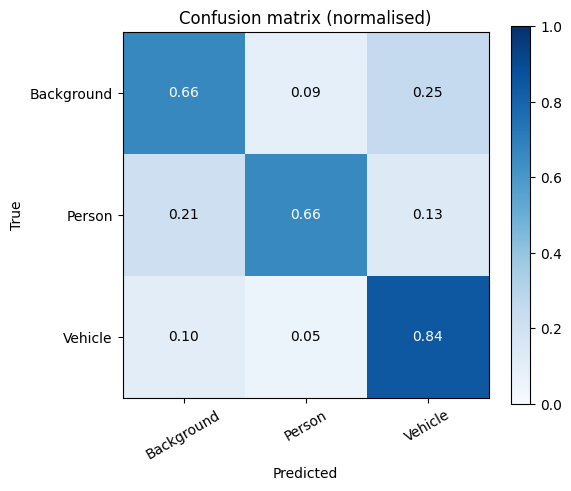

Saved to Drive: /content/drive/MyDrive/segmentation_project/results/confusion_matrix.png
Image 1 predicted classes: ['Background', 'Vehicle']
Image 2 predicted classes: ['Background', 'Vehicle']
Image 3 predicted classes: ['Background', 'Person', 'Vehicle']
Image 4 predicted classes: ['Background', 'Vehicle']


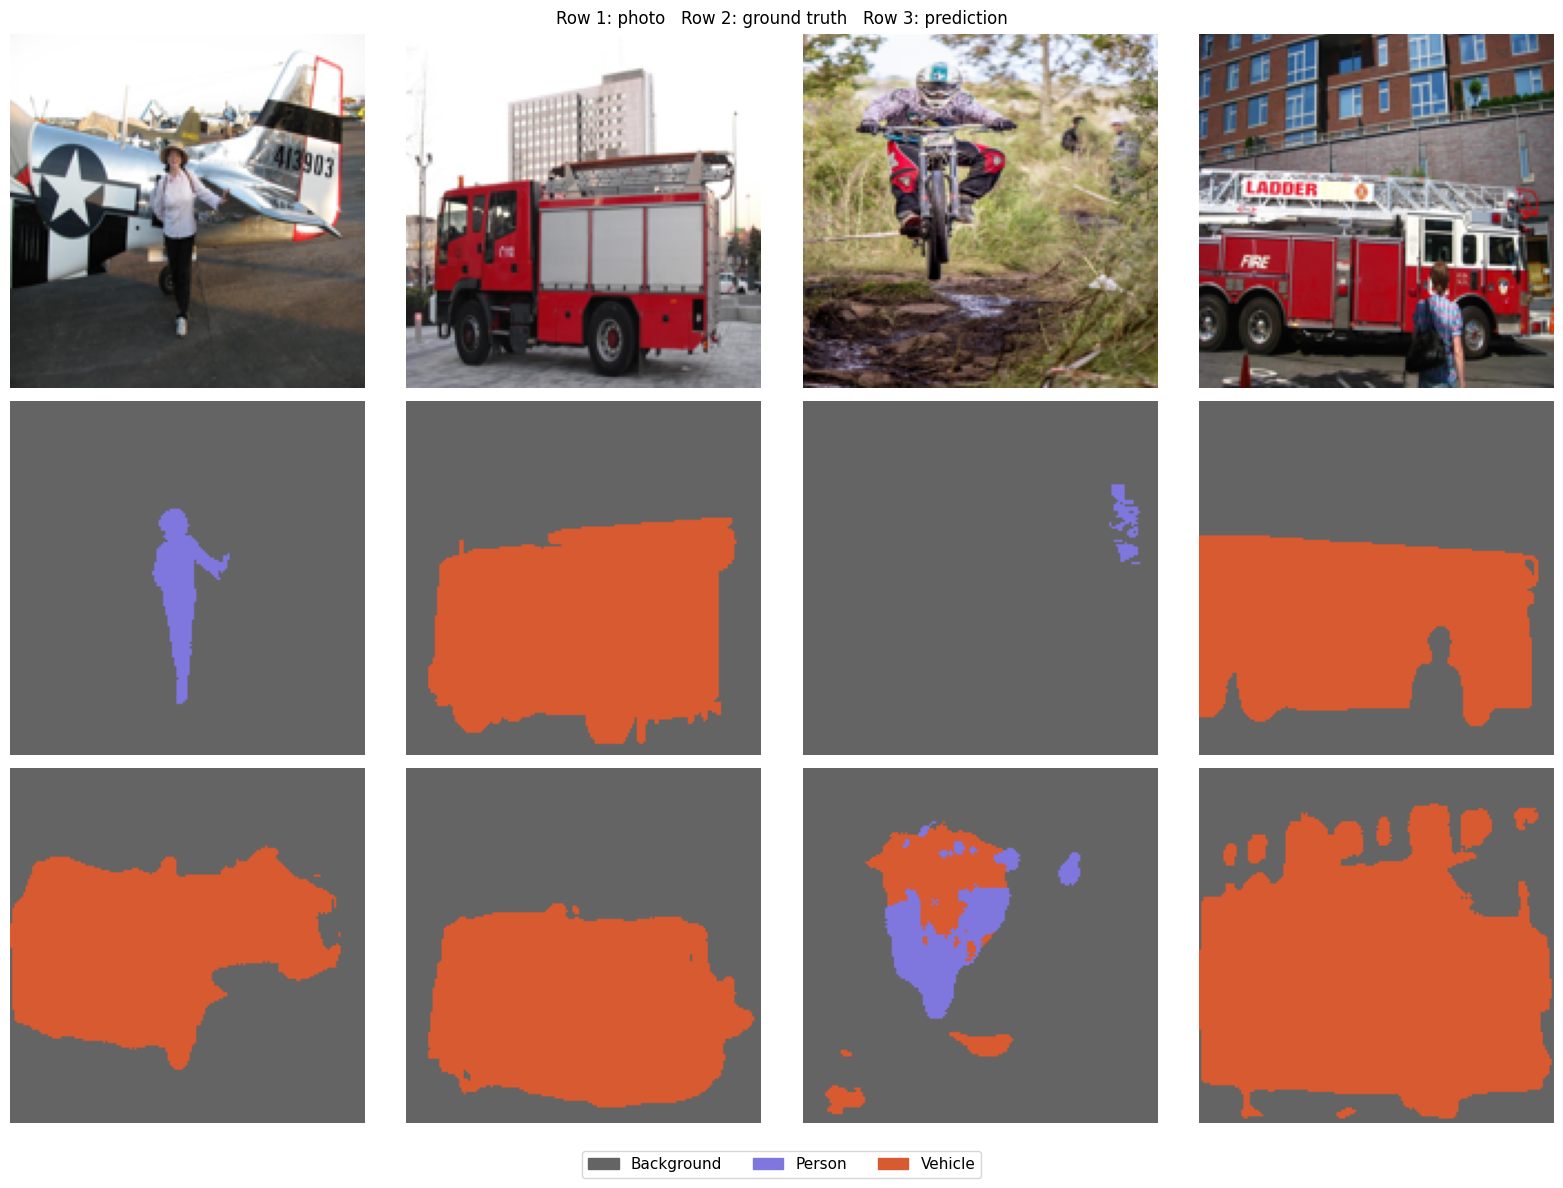

Saved to Drive: /content/drive/MyDrive/segmentation_project/results/sample_predictions.png


In [45]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Fixed confusion matrix + visual predictions
# ═══════════════════════════════════════════════════════════════

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds,
                      labels=list(range(NUM_CLASSES)), normalize="true")
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.set_yticks(range(NUM_CLASSES))
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix (normalised)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm[i,j] > 0.5 else "black", fontsize=10)
plt.colorbar(im, ax=ax)
plt.tight_layout()
cm_path = str(RESULTS_DIR / "confusion_matrix.png")
plt.savefig(cm_path, dpi=120)
plt.show()
print(f"Saved to Drive: {cm_path}")


# ── Fixed visual predictions ──────────────────────────────────

tf_vis = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],   # ← FIXED: was [0.5]*3
        std= [0.229, 0.224, 0.225]    # ← FIXED: was [0.5]*3
    ),
    ToTensorV2(),
])

# Use local SSD test images
test_stems = [p.stem for p in LOCAL_TEST_MASK.glob("*.png")
              if (LOCAL_TEST_IMG / f"{p.stem}.jpg").exists()]

assert len(test_stems) > 0, "No test images found on local SSD!"
show_stems = random.sample(test_stems, min(4, len(test_stems)))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(
    "Row 1: photo   Row 2: ground truth   Row 3: prediction",
    fontsize=12
)

model.eval()
with torch.no_grad():
    for col, stem in enumerate(show_stems):

        # Load from local SSD
        img_pil  = Image.open(LOCAL_TEST_IMG  / f"{stem}.jpg").convert("RGB")
        mask_pil = Image.open(LOCAL_TEST_MASK / f"{stem}.png")

        # Apply correct normalisation
        img_np = np.array(img_pil)
        inp    = tf_vis(image=img_np)["image"].unsqueeze(0).to(device)

        # Get prediction
        pred_np = model(inp).argmax(1).squeeze(0).cpu().numpy()

        # Ground truth
        gt_np = np.array(
            mask_pil.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        ).clip(0, NUM_CLASSES - 1)

        # Display
        axes[0, col].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
        axes[1, col].imshow(mask_to_rgb(gt_np))
        axes[2, col].imshow(mask_to_rgb(pred_np))

        # Print what classes appear in this prediction
        pred_classes = np.unique(pred_np)
        print(f"Image {col+1} predicted classes: "
              f"{[CLASS_NAMES[c] for c in pred_classes]}")

        for r in range(3):
            axes[r, col].axis("off")

patches = [
    mpatches.Patch(color=[c/255 for c in COLORS[i]], label=CLASS_NAMES[i])
    for i in range(NUM_CLASSES)
]
fig.legend(handles=patches, loc="lower center",
           ncol=NUM_CLASSES, fontsize=11, bbox_to_anchor=(0.5, 0))
plt.tight_layout(rect=[0, 0.04, 1, 1])

pred_path = str(RESULTS_DIR / "sample_predictions.png")
plt.savefig(pred_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved to Drive: {pred_path}")

In [46]:

# ═══════════════════════════════════════════════════════════════
# CELL 11 — Summary of everything saved to Drive
# ═══════════════════════════════════════════════════════════════
print("Everything saved to Google Drive under:")
print(f"  {DRIVE_BASE}\n")

files = [
    (CHECKPOINT,                              "Trained model weights"),
    (RESULTS_DIR / "evaluation_results.txt", "Precision/Recall/F1 table"),
    (RESULTS_DIR / "training_curve.png",     "Loss curve over epochs"),
    (RESULTS_DIR / "confusion_matrix.png",   "Per-class confusion matrix"),
    (RESULTS_DIR / "sample_predictions.png", "Visual prediction examples"),
    (RESULTS_DIR / "data_check.png",         "Data sanity check"),
    (TRAIN_IMG_DIR,                          f"Training images ({len(list(TRAIN_IMG_DIR.glob('*.jpg')))} files)"),
    (TRAIN_MASK_DIR,                         f"Training masks  ({len(list(TRAIN_MASK_DIR.glob('*.png')))} files)"),
    (TEST_IMG_DIR,                           f"Test images     ({len(list(TEST_IMG_DIR.glob('*.jpg')))} files)"),
    (TEST_MASK_DIR,                          f"Test masks      ({len(list(TEST_MASK_DIR.glob('*.png')))} files)"),
]

for path, description in files:
    exists = Path(path).exists()
    status = "OK" if exists else "MISSING"
    print(f"  [{status:^7}]  {description}")
    print(f"           {path}")
    print()

print("Next time you open Colab:")
print("  1. Run Cell 1  (install + mount Drive)")
print("  2. Run Cell 2  (imports + settings)")
print("  3. Run Cell 3  (will SKIP download — data already on Drive)")
print("  4. Skip to Cell 9 to evaluate, or Cell 7 to retrain")

Everything saved to Google Drive under:
  /content/drive/MyDrive/segmentation_project

  [  OK   ]  Trained model weights
           /content/drive/MyDrive/segmentation_project/best_model_vehicle.pth

  [  OK   ]  Precision/Recall/F1 table
           /content/drive/MyDrive/segmentation_project/results/evaluation_results.txt

  [  OK   ]  Loss curve over epochs
           /content/drive/MyDrive/segmentation_project/results/training_curve.png

  [  OK   ]  Per-class confusion matrix
           /content/drive/MyDrive/segmentation_project/results/confusion_matrix.png

  [  OK   ]  Visual prediction examples
           /content/drive/MyDrive/segmentation_project/results/sample_predictions.png

  [  OK   ]  Data sanity check
           /content/drive/MyDrive/segmentation_project/results/data_check.png

  [  OK   ]  Training images (1441 files)
           /content/drive/MyDrive/segmentation_project/data/train/images

  [  OK   ]  Training masks  (1441 files)
           /content/drive/MyDrive/